# RL agent sims: analysis of 180-trial behaviour for Low first-seen

Parses RL agent inference-run `.json` files into dataframes + trial lists (accounting for the extra reward fields in the agent `trial end` event). Addresses: **on 180° HighLow trials where the Low wall is seen first, does the agent choose High (i.e. are they reward-maximising)?**

**Model groups (current):**
- `reference` — models 1–10 (baseline)
- `curriculum` — models 21–30 (curriculum-learning agents)
- `higherRND` — models 31–40 (higher training RND value)

Pipeline (`parse_data/`): `identify_sim_filepaths` (enumerate/group models) → `prepare_sim_data` (load + `preprocess_sim`, which also fills the trial-end reward fields across each trial) → split into trials.

In [1]:
import contextlib
import io

import numpy as np
import pandas as pd

import globals
from parse_data import identify_sim_filepaths, prepare_sim_data
import data_extraction.get_indices as get_indices
import analysis.wall_visibility_and_choice as wall_visibility_and_choice

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

# field-of-view (degrees, TOTAL) for the visibility analysis (thetas < fov/2).
# Current agents use 132; this will likely move to 110 to match the human task.
CURRENT_FOV = 132  # agent camera FOV; human-task default is 110.36

# 180 degrees = directly opposite walls = a wall separation of NUM_WALLS / 2 in the octagon
WALL_SEP_180 = globals.NUM_WALLS // 2  # = 4

## Model groups

`group_models` returns only the members present on disk, so group ranges can be edited freely.

In [2]:
GROUPS = {
    'reference':  (1, 10),
    'curriculum': (21, 30),
    'higherRND':  (31, 40),
}

group_members = identify_sim_filepaths.group_models(groups=GROUPS)
for name, members in group_members.items():
    print(f"{name:11s} {GROUPS[name]}: {members}")

reference   (1, 10): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
curriculum  (21, 30): [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
higherRND   (31, 40): [31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


## Parse a single model

Confirm a model loads and that the extra `trial end` reward fields (`trialScores`, `trialRewards`, `playerScores`) are filled across every row of each trial.

In [3]:
def build_sim_trial_summary(trial_list, model_number, player_id=0):
    """One row per trial: walls, reached wall, and the (filled) reward fields."""
    score_cols = globals.PLAYER_SCORE_DICT[player_id]
    reward_cols = globals.PLAYER_TRIAL_REWARD_DICT[player_id]

    def first_value(trial, event, column):
        rows = trial[trial['eventDescription'] == event]
        if rows.empty or column not in rows:
            return float('nan')
        return rows[column].iloc[0]

    records = []
    for trial in trial_list:
        records.append({
            'model': model_number,
            'trialNum': int(trial[globals.TRIAL_NUM].iloc[0]),
            'trialType': first_value(trial, globals.SLICE_ONSET, globals.TRIAL_TYPE),
            'wall1_high': first_value(trial, globals.SLICE_ONSET, globals.WALL_1),
            'wall2_low': first_value(trial, globals.SLICE_ONSET, globals.WALL_2),
            'wall_reached': first_value(trial, globals.SELECTED_TRIGGER_ACTIVATION, globals.WALL_TRIGGERED),
            'player_score': trial[score_cols['score']].iloc[0],
            'trial_score': trial[reward_cols['trial_score']].iloc[0],
            'trial_reward': trial[reward_cols['trial_reward']].iloc[0],
        })
    return pd.DataFrame.from_records(records)


_df, _tl = prepare_sim_data.prepare_single_model_data(1)
print(f"model 1: df {_df.shape}, {len(_tl)} trials")
build_sim_trial_summary(_tl, 1).head()

filepath: /home/tom/Unity/Octagon/simulations/results/260515_0001/2026-06-09_16-17-49.json


Loading complete.
Preprocessing complete.
Simulation preprocessing complete.
model 1: df (46102, 21), 99 trials


,model,trialNum,trialType,wall1_high,wall2_low,wall_reached,player_score,trial_score,trial_reward
0,1,1,HighLow,8.0,1.0,8.0,1.00000000,1.0,0.697000400
1,1,2,HighLow,6.0,8.0,8.0,1.40000000,0.4,-0.005998313
2,1,3,HighLow,6.0,2.0,6.0,2.40000000,1.0,0.625001300
3,1,4,HighLow,2.0,6.0,6.0,2.80000019,0.4,0.069000720
4,1,5,HighLow,8.0,1.0,8.0,3.80000019,1.0,0.615001440


## Load all group models once

Both analyses below reuse these. Loading ~20 models (each 12–24 MB JSON). Slowest step

In [4]:
needed_models = sorted({m for members in group_members.values() for m in members})
models_data = prepare_sim_data.prepare_models_data(model_numbers=needed_models)

# convenience: model_number -> group name
model_to_group = {m: name for name, members in group_members.items() for m in members}
print('loaded models:', list(models_data))

Preparing model 1
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0001/2026-06-09_16-17-49.json


Loading complete.
Preprocessing complete.
Simulation preprocessing complete.
Preparing model 2
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0002/2026-06-09_16-26-59.json


Loading complete.
Preprocessing complete.
Simulation preprocessing complete.
Preparing model 3
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0003/2026-06-09_16-36-30.json


Loading complete.
Preprocessing complete.
Simulation preprocessing complete.
Preparing model 4
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0004/2026-06-09_16-46-01.json


Loading complete.
Preprocessing complete.
Simulation preprocessing complete.
Preparing model 5
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0005/2026-06-09_16-55-47.json


...

Simulation preprocessing complete.
Preparing model 39
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0039/2026-06-17_15-57-41.json


Loading complete.


Preprocessing complete.
Simulation preprocessing complete.
Preparing model 40
filepath: /home/tom/Unity/Octagon/simulations/results/260515_0040/2026-06-17_16-20-12.json


Loading complete.
Preprocessing complete.


Simulation preprocessing complete.
loaded models: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]


## Average trial reward & score by group

In [5]:
summary = pd.concat(
    [build_sim_trial_summary(trial_list, model_num).assign(group=model_to_group[model_num])
     for model_num, (df, trial_list) in models_data.items()],
    ignore_index=True,
)

print('Average over all trials in each group:')
print(summary.groupby('group')[['trial_score', 'trial_reward']].mean())

print('\nMean of per-model means:')
per_model_reward = summary.groupby(['group', 'model'])[['trial_score', 'trial_reward']].mean()
print(per_model_reward.groupby('group').mean())

Average over all trials in each group:
            trial_score  trial_reward
group                                
curriculum  0.940300000   0.495844173
higherRND   0.881500000   0.437238671
reference   0.889090909   0.461228222

Mean of per-model means:
            trial_score  trial_reward
group                                
curriculum  0.940300000   0.495844173
higherRND   0.881500000   0.437238671
reference   0.889090909   0.461228222


## 180° trials where Low is seen first — does the agent choose High?

Reward-maximising play on a HighLow trial is to reach **High**. On a 180° trial the agent typically sees one first.

Using the existing visibility machinery (`first_visible_wall_chosen_session`), restricted to HighLow trials with wall separation 4 (= 180°):
- `first_visible_wall_high` = 1 if the first-seen wall was High, 0 if Low  (wall1 is High, wall2 is Low by convention),
- `first_visible_wall_chosen` = 1 if the first-seen wall was the one reached.


`inferred_choice=False` (solo agent). Visibility uses `CURRENT_FOV`.

In [6]:
def p_choose_high_when_low_first(first_visible_wall_chosen, first_visible_wall_high):
    """Return (probability, n_chose_high, n_low_first_trials) for one model.
    Low seen first => first_visible_wall_high == 0; High chosen => first-seen not chosen."""
    valid = (~np.isnan(first_visible_wall_high)) & (~np.isnan(first_visible_wall_chosen))
    low_first = valid & (first_visible_wall_high == 0)
    n = int(low_first.sum())
    if n == 0:
        return np.nan, 0, 0
    chose_high = int(np.sum(first_visible_wall_chosen[low_first] == 0))
    return chose_high / n, chose_high, n


records = []
for model_num, (df, trial_list) in models_data.items():
    # first_visible_wall_chosen_session is chatty (debug prints); silence it
    with contextlib.redirect_stdout(io.StringIO()):
        chosen, high = wall_visibility_and_choice.first_visible_wall_chosen_session(
            trial_list, player_id=0, current_fov=CURRENT_FOV, wall_sep=WALL_SEP_180,
            trial_type=globals.HIGH_LOW, inferred_choice=False)
    p, k, n = p_choose_high_when_low_first(chosen, high)
    records.append({'group': model_to_group[model_num], 'model': model_num,
                    'p_choose_high_given_low_first': p, 'n_chose_high': k, 'n_low_first_trials': n})

per_model = pd.DataFrame.from_records(records)
per_model

,group,model,p_choose_high_given_low_first,n_chose_high,n_low_first_trials
0,reference,1,0.055555556,1,18
1,reference,2,1.000000000,15,15
2,reference,3,0.000000000,0,9
3,reference,4,0.000000000,0,14
4,reference,5,0.000000000,0,19
5,reference,6,0.500000000,1,2
6,reference,7,0.000000000,0,14
7,reference,8,0.000000000,0,20
8,reference,9,0.000000000,0,12
9,reference,10,0.000000000,0,13


### Group summary

Two pooled estimates per group: the **mean of per-model probabilities**, and a **trial-pooled** probability (total High-choices / total Low-seen-first trials) which is robust to models with few qualifying trials.

In [7]:
group_summary = per_model.groupby('group').agg(
    mean_p_per_model=('p_choose_high_given_low_first', 'mean'),
    total_chose_high=('n_chose_high', 'sum'),
    total_low_first_trials=('n_low_first_trials', 'sum'),
)
group_summary['pooled_p'] = group_summary['total_chose_high'] / group_summary['total_low_first_trials']
group_summary

,mean_p_per_model,total_chose_high,total_low_first_trials,pooled_p
group,,,,
curriculum,0.217878788,62,243,0.255144033
higherRND,0.100000000,18,237,0.075949367
reference,0.155555556,17,136,0.125000000


## Variability across individual models

How much do individual agent models differ in P(choose High | Low seen first) on 180° trials, within each group?

Models with fewer than `MIN_LOW_FIRST_TRIALS` qualifying Low-seen-first trials are excluded.
- **Left**: one bar per included model (annotated with `n`, the number of qualifying trials).
- **Right**: the per-model values as a distribution within each group; the black bar is the group mean of per-model probabilities.

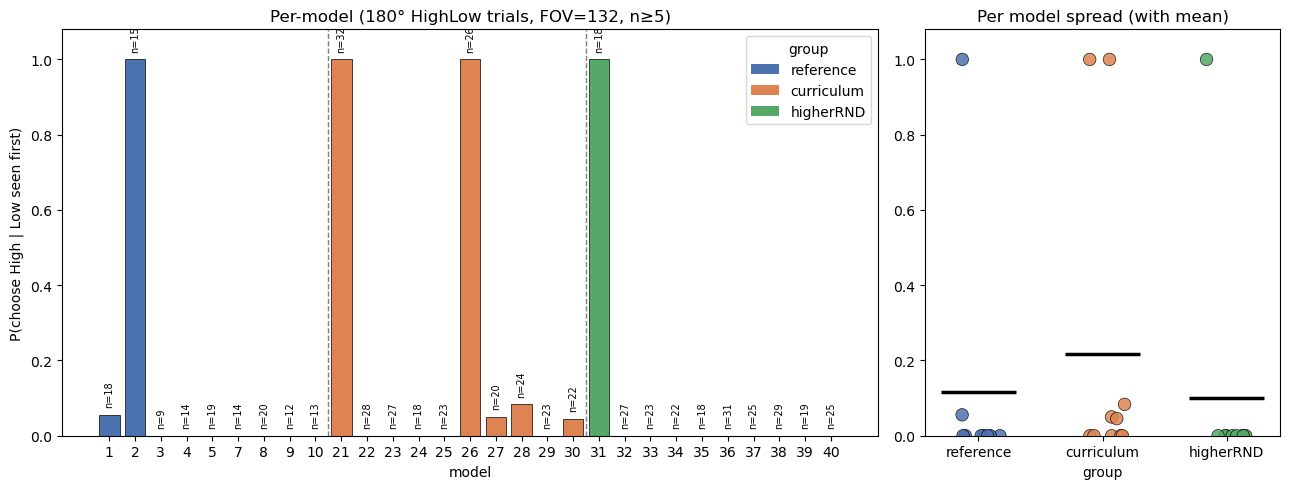

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

palette = {'reference': '#4C72B0', 'curriculum': '#DD8452', 'higherRND': '#55A868'}
MIN_LOW_FIRST_TRIALS = 5  # exclude models with too few Low-seen-first 180° trials
order = [g for g in ['reference', 'curriculum', 'higherRND'] if g in per_model['group'].unique()]

pm = per_model[per_model['n_low_first_trials'] >= MIN_LOW_FIRST_TRIALS].copy()
pm['group'] = pd.Categorical(pm['group'], categories=order, ordered=True)
pm = pm.sort_values(['group', 'model']).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [2.3, 1]})

# --- Panel A: per-model bars ---
ax = axes[0]
x = np.arange(len(pm))
ax.bar(x, pm['p_choose_high_given_low_first'], color=[palette[g] for g in pm['group']],
       edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(pm['model'])
ax.set_xlabel('model')
ax.set_ylabel('P(choose High | Low seen first)')
ax.set_ylim(0, 1.08)
ax.set_title(f'Per-model (180\u00b0 HighLow trials, FOV={CURRENT_FOV}, n\u2265{MIN_LOW_FIRST_TRIALS})')
for xi, (p, n) in enumerate(zip(pm['p_choose_high_given_low_first'], pm['n_low_first_trials'])):
    ax.text(xi, (0 if np.isnan(p) else p) + 0.02, f'n={n}', ha='center', va='bottom',
            fontsize=7, rotation=90)
# separators between groups
for b in np.cumsum([(pm['group'] == g).sum() for g in order])[:-1]:
    ax.axvline(b - 0.5, color='grey', ls='--', lw=1)
ax.legend(handles=[Patch(facecolor=palette[g], label=g) for g in order], title='group')

# --- Panel B: per-group distribution of per-model probabilities ---
ax = axes[1]
sns.stripplot(data=pm, x='group', y='p_choose_high_given_low_first', order=order,
              hue='group', palette=palette, size=9, jitter=0.18, alpha=0.85,
              edgecolor='black', linewidth=0.5, legend=False, ax=ax)
means = pm.groupby('group', observed=True)['p_choose_high_given_low_first'].mean()
for i, g in enumerate(order):
    ax.hlines(means[g], i - 0.3, i + 0.3, color='black', lw=2.5, zorder=5)
ax.set_ylim(0, 1.08)
ax.set_xlabel('group')
ax.set_ylabel('')
ax.set_title('Per model spread (with mean)')

plt.tight_layout()
plt.show()

## Why High isn't chosen: reward vs perception (models 2/21/26 vs 0% models)

Comparing the three near-100% ChooseHigh models against a set of 0% models, on the 180° Low-seen-first trials, to ask two things:
1. **Is reaching High actually worth it** once the 180° detour cost is paid? (`trial_score` = terminal reward, `trial_reward` = net of step/time penalties.)
2. **Do the ChooseHigh agents rotate enough to bring High into view**, while the 0% models stay locked on the visible Low? FOV is 132° total, so a wall 180° away only enters view after a turn of ~`180 − 66 = 114°`.

Reuses the already-loaded `models_data`; no extra loading.

In [9]:
HIGH_SEEKERS = [2, 21, 26]
ZERO_MODELS  = [5, 8, 22, 25]
HALF_FOV = CURRENT_FOV / 2

def rotation_metrics(trial):
    """Heading-yaw rotation over the slice-onset -> trigger window (degrees)."""
    so, ta = get_indices.get_indices_slice_onset_trigger_activation(trial)
    yaw = trial[globals.PLAYER_0_YROT].values[so:ta + 1]
    yaw = yaw[~np.isnan(yaw)]
    if len(yaw) < 3:
        return np.nan, np.nan, np.nan, np.nan
    unw = np.rad2deg(np.unwrap(np.deg2rad(yaw)))
    total = float(np.abs(np.diff(unw)).sum())
    net = float(abs(unw[-1] - unw[0]))
    return total, net, total - net, float(unw.max() - unw.min())  # total, net, excess, range

rows = []
for m in HIGH_SEEKERS + ZERO_MODELS:
    _, trial_list = models_data[m]
    grp = 'high-seeker' if m in HIGH_SEEKERS else 'zero'
    for trial in trial_list:
        if trial[globals.TRIAL_TYPE].unique()[0] != globals.HIGH_LOW:
            continue
        if get_indices.get_wall_difference(trial=trial) != WALL_SEP_180:
            continue
        with contextlib.redirect_stdout(io.StringIO()):
            first_vis_high, _ = wall_visibility_and_choice.get_first_visible_wall_trial(trial, 0, CURRENT_FOV)
        if np.isnan(first_vis_high):
            continue  # both/neither wall visible at onset, or trial too short
        wall1 = get_indices.get_walls(trial)[0]
        sel = trial[trial['eventDescription'] == globals.SELECTED_TRIGGER_ACTIVATION]
        wall_reached = sel[globals.WALL_TRIGGERED].dropna().iloc[0]
        total, net, excess, rng = rotation_metrics(trial)
        rows.append(dict(model=m, group=grp,
                         low_seen_first=bool(first_vis_high == 0),
                         high_reached=bool(wall_reached == wall1),
                         trial_score=trial[globals.PLAYER_0_TRIAL_SCORE].iloc[0],
                         trial_reward=trial[globals.PLAYER_0_TRIAL_REWARD].iloc[0],
                         rot_total=total, rot_net=net, rot_excess=excess, rot_range=rng))

trials_180 = pd.DataFrame(rows)
low_first = trials_180[trials_180.low_seen_first]
print(f"180° HighLow trials: {len(trials_180)} | Low-seen-first: {len(low_first)}\n")

print('ANALYSIS 1 - realised reward on 180° Low-first trials, by wall reached:')
print(low_first.groupby('high_reached').agg(
    n=('trial_reward', 'size'),
    mean_trial_score=('trial_score', 'mean'),
    mean_trial_reward=('trial_reward', 'mean')).round(3))

print('\nANALYSIS 2 - heading rotation on 180° Low-first trials, by group (degrees):')
print(low_first.groupby('group').agg(
    n=('rot_total', 'size'),
    rot_net=('rot_net', 'mean'),
    rot_range=('rot_range', 'mean'),
    rot_excess=('rot_excess', 'mean')).round(1))

180° HighLow trials: 323 | Low-seen-first: 163

ANALYSIS 1 - realised reward on 180° Low-first trials, by wall reached:
               n  mean_trial_score  mean_trial_reward
high_reached                                         
False         90               0.4             -0.033
True          73               1.0              0.541

ANALYSIS 2 - heading rotation on 180° Low-first trials, by group (degrees):
              n  rot_net  rot_range  rot_excess
group                                          
high-seeker  73    196.0      222.9       348.2
zero         90     46.1       73.1       357.3


### Figures
- **Left** — Analysis 1: terminal vs net reward for reaching Low  vs High.
- **Middle** — Analysis 2: net rotation, angular range, and excess (back-and-forth) rotation by group
- **Right** — example |heading change| vs time for a ChooseHigh model (21) and a 0% model (22) on Low-first trials

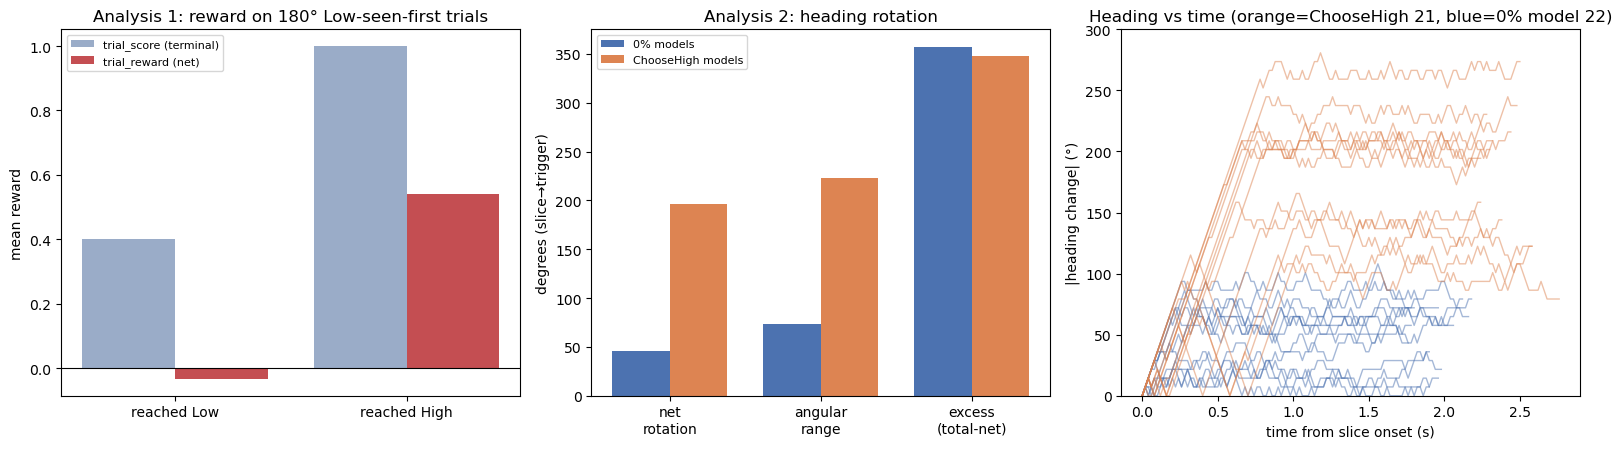

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

# Panel A: reward by wall reached
ax = axes[0]
agg = low_first.groupby('high_reached').agg(score=('trial_score', 'mean'),
                                            reward=('trial_reward', 'mean'),
                                            n=('trial_reward', 'size'))
xs = [0, 1]
ax.bar([x - 0.2 for x in xs], [agg.loc[False, 'score'], agg.loc[True, 'score']],
       width=0.4, label='trial_score (terminal)', color='#9aacc8')
ax.bar([x + 0.2 for x in xs], [agg.loc[False, 'reward'], agg.loc[True, 'reward']],
       width=0.4, label='trial_reward (net)', color='#c44e52')
ax.axhline(0, color='k', lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(['reached Low', 'reached High'])
ax.set_ylabel('mean reward'); ax.set_title('Analysis 1: reward on 180° Low-seen-first trials')
ax.legend(fontsize=8, loc='upper left')

# Panel B: rotation metrics by group
ax = axes[1]
g = low_first.groupby('group')[['rot_net', 'rot_range', 'rot_excess']].mean()
mx = np.arange(3); w = 0.38
ax.bar(mx - w/2, g.loc['zero'], width=w, label='0% models', color='#4C72B0')
ax.bar(mx + w/2, g.loc['high-seeker'], width=w, label='ChooseHigh models', color='#DD8452')
ax.set_xticks(mx); ax.set_xticklabels(['net\nrotation', 'angular\nrange', 'excess\n(total-net)'])
ax.set_ylabel('degrees (slice→trigger)'); ax.set_title('Analysis 2: heading rotation')
ax.legend(fontsize=8)

# Panel C: example heading traces, seeker 21 vs zero 22
ax = axes[2]
def lowfirst_traces(trial_list, n_max=12):
    out = []
    for trial in trial_list:
        if trial[globals.TRIAL_TYPE].unique()[0] != globals.HIGH_LOW: continue
        if get_indices.get_wall_difference(trial=trial) != WALL_SEP_180: continue
        with contextlib.redirect_stdout(io.StringIO()):
            fvh, _ = wall_visibility_and_choice.get_first_visible_wall_trial(trial, 0, CURRENT_FOV)
        if np.isnan(fvh) or fvh != 0: continue
        so, ta = get_indices.get_indices_slice_onset_trigger_activation(trial)
        yaw = trial[globals.PLAYER_0_YROT].values[so:ta + 1]; yaw = yaw[~np.isnan(yaw)]
        if len(yaw) < 3: continue
        rel = np.rad2deg(np.unwrap(np.deg2rad(yaw))); rel = rel - rel[0]
        out.append((np.arange(len(rel)) / globals.RECORDING_FREQUENCY, np.abs(rel)))
        if len(out) >= n_max: break
    return out

for t, rel in lowfirst_traces(models_data[22][1]):
    ax.plot(t, rel, color='#4C72B0', alpha=0.5, lw=1)
for t, rel in lowfirst_traces(models_data[21][1]):
    ax.plot(t, rel, color='#DD8452', alpha=0.5, lw=1)
ax.set_xlabel('time from slice onset (s)'); ax.set_ylabel('|heading change| (°)')
ax.set_title('Heading vs time (orange=ChooseHigh 21, blue=0% model 22)'); ax.set_ylim(0, 300)

plt.tight_layout(); plt.show()

### High-wall first-visible marker

The angle a wall must be rotated into view is **not** a constant — it depends on the agent's heading relative to the wall at slice onset. So instead of a fixed reference line, this uses the repository's angle-to-wall analysis (`trajectory_headangle.get_wall_visible`) to mark, on each Low-seen-first trial, the moment the **angle to the High wall first falls below the FOV half-angle** (66° = 132°/2) — i.e. when High first enters view. Heading is taken from the same smoothed head-angle vectors the visibility code uses, so the marker is time-aligned to the trace. Traces without a marker are trials where High never entered the FOV.

model 22: High entered FOV on 0/12 Low-first trials shown


model 21: High entered FOV on 12/12 Low-first trials shown


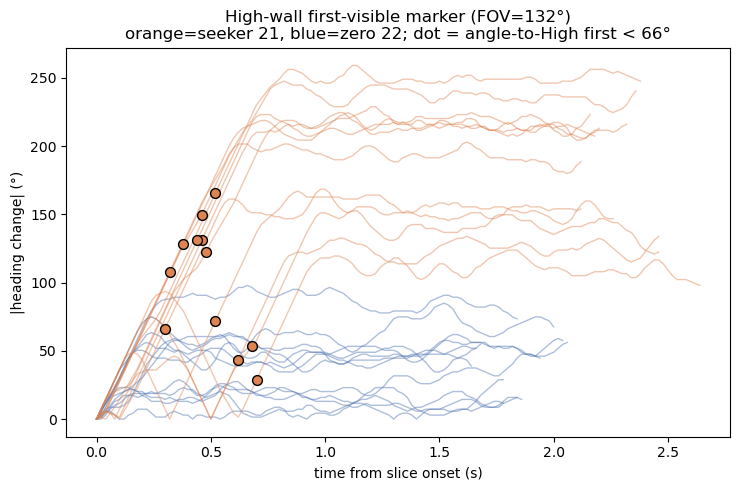

In [11]:
import trajectory_analysis.trajectory_headangle as trajectory_headangle
import trajectory_analysis.trajectory_vectors as trajectory_vectors

def lowfirst_traces_with_visibility(trial_list, n_max=12):
    """|heading change| traces + the column where the High wall first enters the FOV."""
    out = []
    for trial in trial_list:
        if trial[globals.TRIAL_TYPE].unique()[0] != globals.HIGH_LOW: continue
        if get_indices.get_wall_difference(trial=trial) != WALL_SEP_180: continue
        with contextlib.redirect_stdout(io.StringIO()):
            fvh, _ = wall_visibility_and_choice.get_first_visible_wall_trial(trial, 0, CURRENT_FOV)
        if np.isnan(fvh) or fvh != 0: continue
        wall_visible = trajectory_headangle.get_wall_visible(trial=trial, player_id=0, current_fov=CURRENT_FOV)
        if isinstance(wall_visible, float) and np.isnan(wall_visible): continue  # too short
        head_vecs = trajectory_headangle.get_smoothed_player_head_angle_vectors_for_trial(
            trajectory_vectors.extract_trial_player_headangles(trial=trial, player_id=0), window_size=5)
        heading = np.rad2deg(np.unwrap(np.arctan2(head_vecs[1], head_vecs[0])))
        rel = np.abs(heading - heading[0])
        t = np.arange(len(rel)) / globals.RECORDING_FREQUENCY
        high_visible = wall_visible[get_indices.get_walls(trial)[0] - 1]  # High = wall1, row = wall_num - 1
        first_col = int(np.argmax(high_visible)) if high_visible.any() else None
        out.append((t, rel, first_col))
        if len(out) >= n_max: break
    return out

fig, ax = plt.subplots(figsize=(7.5, 5))
for color, model in [('#4C72B0', 22), ('#DD8452', 21)]:
    n_marked = 0
    traces = lowfirst_traces_with_visibility(models_data[model][1])
    for t, rel, first_col in traces:
        ax.plot(t, rel, color=color, alpha=0.45, lw=1)
        if first_col is not None:
            ax.scatter(t[first_col], rel[first_col], color=color, edgecolor='black', s=50, zorder=5)
            n_marked += 1
    print(f'model {model}: High entered FOV on {n_marked}/{len(traces)} Low-first trials shown')

ax.set_xlabel('time from slice onset (s)')
ax.set_ylabel('|heading change| (\u00b0)')
ax.set_title(f'High-wall first-visible marker (FOV={CURRENT_FOV}\u00b0)\n'
             f'orange=seeker 21, blue=zero 22; dot = angle-to-High first < {CURRENT_FOV/2:.0f}\u00b0')
plt.tight_layout(); plt.show()

## Next steps

- **Calibrate `CURRENT_FOV`** to the agent's real camera FOV; the first-seen-wall determination depends on it.
- Complement P(High | Low first) with P(High | High first) and the overall P(first-seen chosen), to separate *reward-seeking* from *go-to-first-wall-seen* behaviour.
- Stats across models (e.g. per-model probability as the unit) once a difference between groups appears.